# 1. Predict orders that are likely to be canceled

Epoch 1/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - accuracy: 0.9808 - loss: 0.0897 - val_accuracy: 0.9816 - val_loss: 0.0909
Epoch 2/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.9833 - loss: 0.0760 - val_accuracy: 0.9814 - val_loss: 0.0898
Epoch 3/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9829 - loss: 0.0778 - val_accuracy: 0.9816 - val_loss: 0.0843
Epoch 4/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.9831 - loss: 0.0763 - val_accuracy: 0.9815 - val_loss: 0.0888
Epoch 5/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9836 - loss: 0.0748 - val_accuracy: 0.9817 - val_loss: 0.0822
Epoch 6/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9833 - loss: 0.0761 - val_accuracy: 0.9815 - val_loss: 0.0830
Epoch 7/20
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 18s 4ms/step - accuracy: 0.9830 - loss: 0.0766 - val_accuracy: 0.9827 - val_loss: 0.1314
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 5.


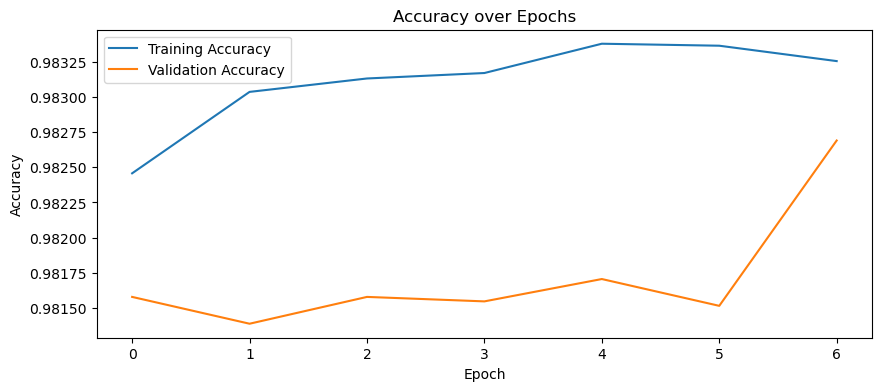

In [20]:
import pandas as pd
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Load data
data = pd.read_csv('cleaned_data.csv')

# Prepare the data
data['Canceled'] = data['QuantityCanceled'].apply(lambda x: 1 if x > 0 else 0)
X = data[['Quantity', 'UnitPrice', 'TotalPrice']]
y = data['Canceled']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define Early Stopping callback with reduced patience
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

# Build the optimized model
model = keras.Sequential([
    layers.BatchNormalization(input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model with a slightly higher learning rate to speed up convergence
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with larger batch size and reduced epochs
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, callbacks=[early_stopping], verbose=1)

# Save the model
model.save('order_cancellation_model_optimized.keras')

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {accuracy:.4f}')

# Generate classification report and confusion matrix
y_pred = (model.predict(X_test) > 0.5).astype("int32")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()


# 2. Forecast daily sales

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 581ms/step - loss: 0.0252 - val_loss: 0.0616
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0187 - val_loss: 0.0483
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0154 - val_loss: 0.0607
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0150 - val_loss: 0.0525
Test Loss (MSE): 0.0474


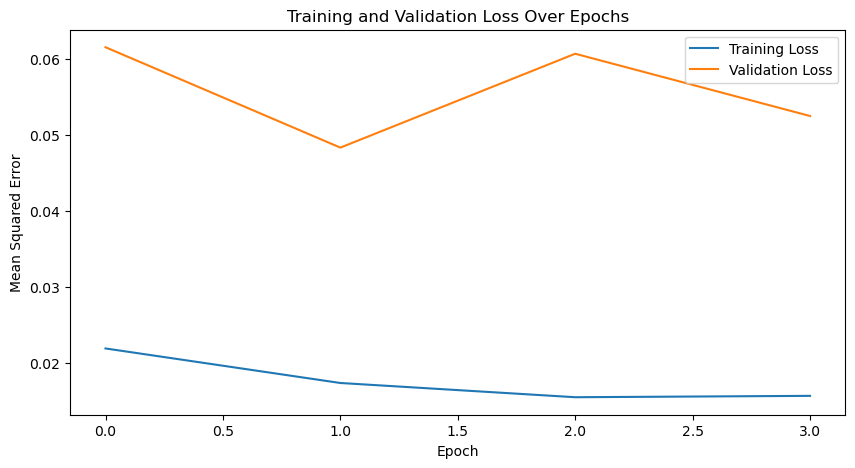

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 510ms/step


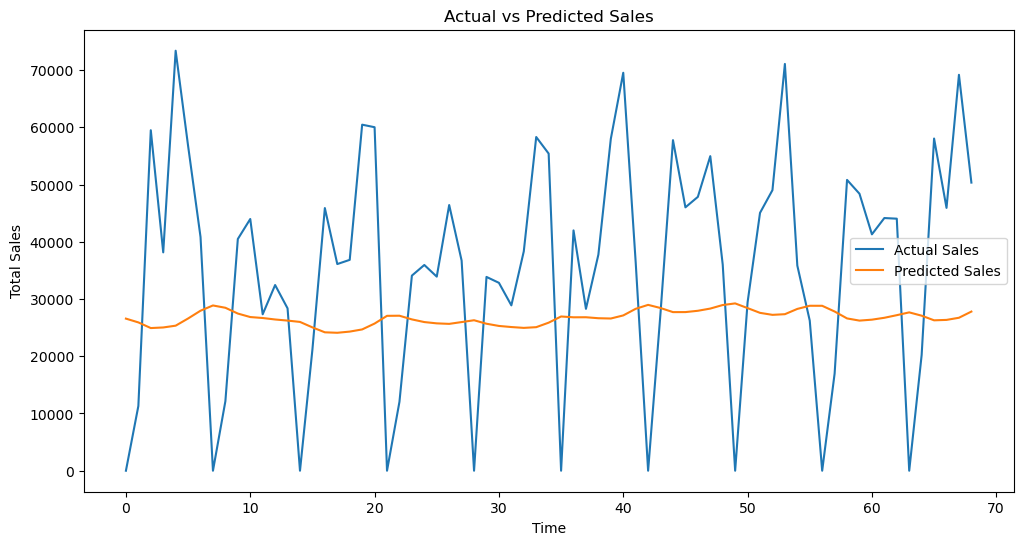

Time taken: 20.64 seconds


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

# Measure execution time
start_time = time.time()

# Load data
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data.set_index('InvoiceDate', inplace=True)
daily_sales = data.resample('D').sum()['TotalPrice']

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
daily_sales_scaled = scaler.fit_transform(daily_sales.values.reshape(-1, 1))

# Create the dataset
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 30
X, y = create_dataset(daily_sales_scaled, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Define EarlyStopping callback
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Use CuDNNLSTM if running on a GPU for faster performance
if tf.config.list_physical_devices('GPU'):
    lstm_layer = layers.CuDNNLSTM
else:
    lstm_layer = layers.LSTM

# Build the optimized LSTM model with smaller architecture
model = tf.keras.Sequential([
    lstm_layer(32, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    lstm_layer(16),
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mean_squared_error')

# Train the model with EarlyStopping and fewer epochs
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1, callbacks=[early_stopping], verbose=1)

# Save the model
model.save('sales_forecasting_model_fast.keras')

# Evaluate the model
loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}')

# Plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.title('Training and Validation Loss Over Epochs')
plt.show()

# Make predictions
y_pred = model.predict(X_test)
y_pred_inverse = scaler.inverse_transform(y_pred)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted
plt.figure(figsize=(12, 6))
plt.plot(y_test_inverse, label='Actual Sales')
plt.plot(y_pred_inverse, label='Predicted Sales')
plt.xlabel('Time')
plt.ylabel('Total Sales')
plt.legend()
plt.title('Actual vs Predicted Sales')
plt.show()

# Measure end time
end_time = time.time()
print(f'Time taken: {end_time - start_time:.2f} seconds')


# 3. Build a fraud detection model based on canceled transactions

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, callbacks, Sequential
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# Data preprocessing
data['Fraud'] = (data['QuantityCanceled'] > 0).astype(int)

# Select features and labels
X = data[['Quantity', 'UnitPrice', 'TotalPrice']]
y = data['Fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create an efficient data pipeline
batch_size = 128  # Increase batch_size to reduce the number of updates per epoch
train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Build a simplified model
model = Sequential([
    layers.Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', AUC(name='auc')])

# Define EarlyStopping and ModelCheckpoint
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
model_checkpoint = callbacks.ModelCheckpoint('best_fraud_detection_model.keras', save_best_only=True)

# Train the model
history = model.fit(train_ds, 
                    validation_data=test_ds, 
                    epochs=10, 
                    callbacks=[early_stopping, model_checkpoint],
                    verbose=1)

# Evaluate the model
loss, accuracy, auc = model.evaluate(test_ds)
print(f'Test Accuracy: {accuracy:.4f}')
print(f'Test AUC: {auc:.4f}')


Epoch 1/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.9551 - auc: 0.5694 - loss: 0.2098 - val_accuracy: 0.9816 - val_auc: 0.7003 - val_loss: 0.0863
Epoch 2/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9815 - auc: 0.7228 - loss: 0.0847 - val_accuracy: 0.9819 - val_auc: 0.7376 - val_loss: 0.0819
Epoch 3/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9820 - auc: 0.7487 - loss: 0.0793 - val_accuracy: 0.9826 - val_auc: 0.7525 - val_loss: 0.0763
Epoch 4/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9830 - auc: 0.7824 - loss: 0.0731 - val_accuracy: 0.9842 - val_auc: 0.8045 - val_loss: 0.0696
Epoch 5/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9845 - auc: 0.8272 - loss: 0.0667 - val_accuracy: 0.9867 - val_auc: 0.8576 - val_loss: 0.0635
Epoch 6/10
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9864 - auc: 0.8670 - loss: 0.0615 - val_accuracy: 0.9875 - val_auc: 0.8901 - val_loss: 0.0579
Epoch 7/10
2456/2456 ━━━━━

# 4.  Build a machine learning model to detect fraud in transactions based on certain transaction features

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Create a column to indicate fraud
data['Fraud'] = (data['QuantityCanceled'] > 0).astype(int)

# Select features and labels
X = data[['Quantity', 'UnitPrice', 'TotalPrice']]
y = data['Fraud']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simpler model to increase speed
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with fewer epochs and reduce the batch_size
callbacks = [EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]

model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

# Save the model
model.save('fraud_detection_model.keras')


Epoch 1/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 63s 3ms/step - accuracy: 0.9803 - loss: 0.1015 - val_accuracy: 0.9857 - val_loss: 0.0662
Epoch 2/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step - accuracy: 0.9868 - loss: 0.0603 - val_accuracy: 0.9882 - val_loss: 0.0468
Epoch 3/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - accuracy: 0.9896 - loss: 0.0437 - val_accuracy: 0.9910 - val_loss: 0.0343
Epoch 4/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 73s 4ms/step - accuracy: 0.9915 - loss: 0.0326 - val_accuracy: 0.9928 - val_loss: 0.0309
Epoch 5/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 56s 3ms/step - accuracy: 0.9935 - loss: 0.0261 - val_accuracy: 0.9936 - val_loss: 0.0241
Epoch 6/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 0.9947 - loss: 0.0232 - val_accuracy: 0.9944 - val_loss: 0.0202
Epoch 7/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 82s 3ms/step - accuracy: 0.9952 - loss: 0.0201 - val_accuracy: 0.9952 - val_loss: 0.0186
Epoch 8/20
17679/17679 ━━━━━━━━━━━━━━━━━━━━ 46s 3ms/step - accuracy: 

# 5. Predict the long-term value of customers

In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Load data
data = pd.read_csv('cleaned_data.csv')

# Specify the necessary columns
data = data[['CustomerID', 'Quantity', 'UnitPrice', 'QuantityCanceled', 'TotalPrice', 'InvoiceNo']]

# Calculate CLV efficiently using NumPy
clv = data.groupby('CustomerID').agg({'TotalPrice': 'sum', 'InvoiceNo': 'count'})
clv['CLV'] = clv['TotalPrice'] / clv['InvoiceNo']
data = data.merge(clv[['CLV']], on='CustomerID', how='left')

# Prepare the data
X = data[['Quantity', 'UnitPrice', 'QuantityCanceled', 'TotalPrice']]
y = data['CLV']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build a simpler model to increase speed
model = keras.Sequential([
    layers.Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)  # Đầu ra cho hồi quy
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Using Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train the model
model.fit(X_train_scaled, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stopping])

# Evaluate the model
loss = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss:.4f}')

# Save the model
model.save('customer_lifetime_value_model.keras')


Epoch 1/50
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 5s 962us/step - loss: 1977.4180 - val_loss: 1171.3833
Epoch 2/50
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1474.7738 - val_loss: 1150.4418
Epoch 3/50
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - loss: 1200.5668 - val_loss: 1152.4493
Epoch 4/50
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 1044.2686 - val_loss: 1164.8491
Epoch 5/50
4420/4420 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - loss: 930.3216 - val_loss: 1163.9384
2456/2456 ━━━━━━━━━━━━━━━━━━━━ 2s 900us/step - loss: 1032.9502
Test Loss: 1087.2933
